In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# npz = np.load(Path("data/Gasecki/Gasecki_data_corr_total.npz"), allow_pickle=True)
# gasecki_e_xy = npz["E_xy"]

npz = np.load(Path("data/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)
sobieski_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)
# matka_boska_e_xy = npz["E_xy"]

npz = np.load(Path("data/Blank_PcbCu/GEM_Cr_PBS1_Blank_PcbCu_ArCO2_75_25_Gain_35_Thr_35_HV_3640_Xray_50kV_04mA_part_001_GainCorr.pcap.dat.npz"), allow_pickle=True)
cu_e_xy = npz["E_xy"]


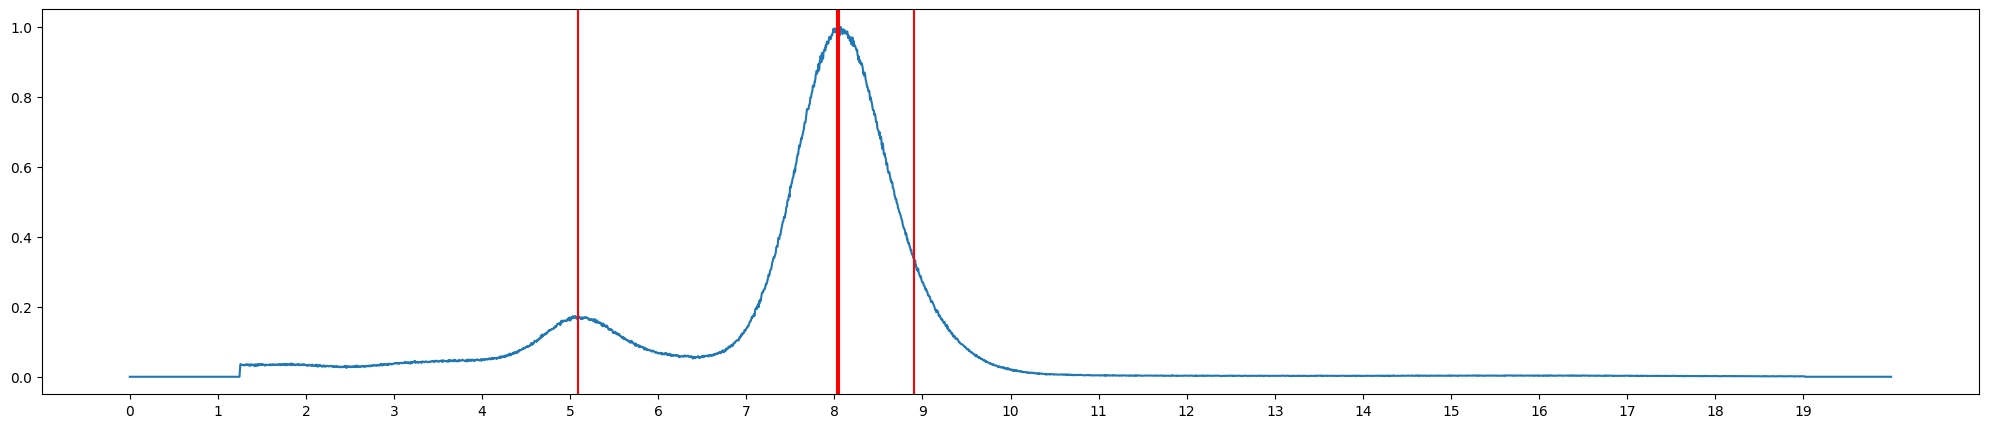

In [3]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

peaks_cu = [1000, 1614]
energies_cu = [5.088, 8.046]


# energy_range, spectra = DataPreprocessor.processed_spectra(gaussian(cu_e_xy, sigma=1, channel_axis=-1), peaks_cu, energies_cu)
# spectrum = spectra[50, 50]
energy_range, spectrum = DataPreprocessor.processed_spectrum(np.average(cu_e_xy, axis=(0,1)), peaks_cu, energies_cu)

plt.figure(figsize=(25, 5))
plt.plot(energy_range, spectrum)
plt.xticks(range(20))
plt.axvline(8.04778, color="red")
plt.axvline(8.04778-2.96, color="red")
plt.axvline(8.02783, color="red")
plt.axvline(8.90529, color="red")

# plt.figure(123123)
# peaks_sobieski = [817, 1016,1347, 1598]
# energies_sobieski =[6.405, 8.046, 10.551, 12.614] 

# energy_range, spectra = DataPreprocessor.processed_spectra(gaussian(sobieski_e_xy, sigma=2, channel_axis=-1), peaks_sobieski, energies_sobieski)
# spectrum = spectra[25, 25]
# # print(np.min(spectrum))
# # energy_range, spectrum = DataPreprocessor.processed_spectrum(np.average(cu_e_xy, axis=(0,1)), peaks_cu, energies_cu)

# plt.figure(figsize=(25, 5))
# # plt.plot(energy_range, spectrum)
# plt.plot(energy_range, spectrum)
# plt.xticks(range(20))
# plt.axvline(energies_sobieski[0], color="black")
# plt.axvline(energies_sobieski[1], color="black")
# plt.axvline(energies_sobieski[2], color="black")
# plt.axvline(energies_sobieski[3], color="black")

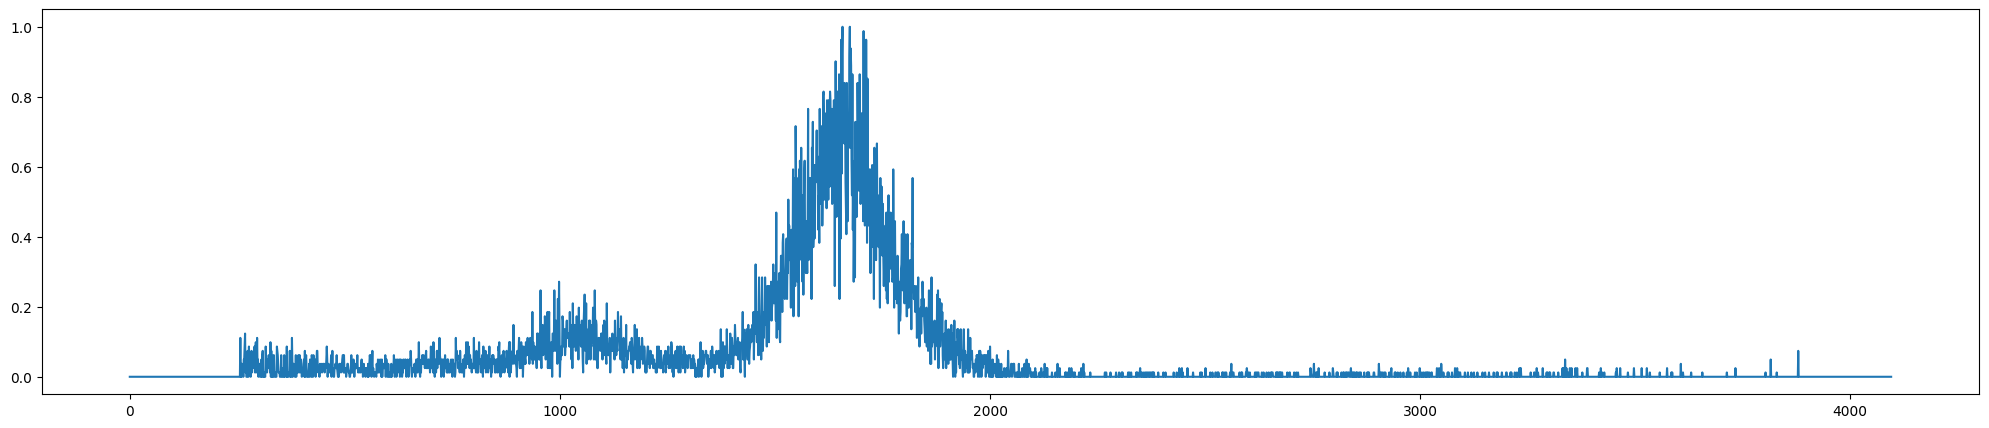

In [75]:
from src.FeatureEnhancer import FeatureEnhancer

plt.figure(figsize=(25, 5))
plt.plot(FeatureEnhancer._metropolis_hasting_mcmc(spectrum, steps=20000))
# max_positions = np.argmax(spectra, axis=2)
# plt.imshow(max_positions, aspect="auto")
# plt.colorbar()


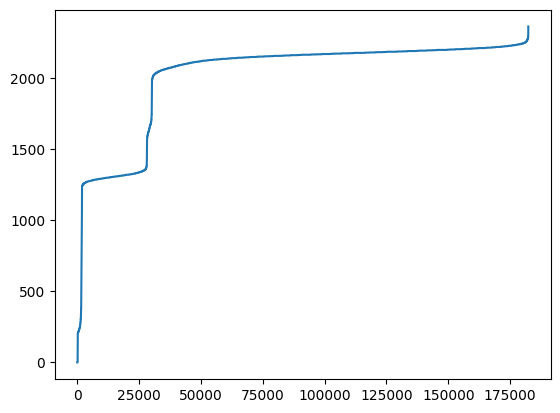

<Figure size 1000x1000 with 0 Axes>

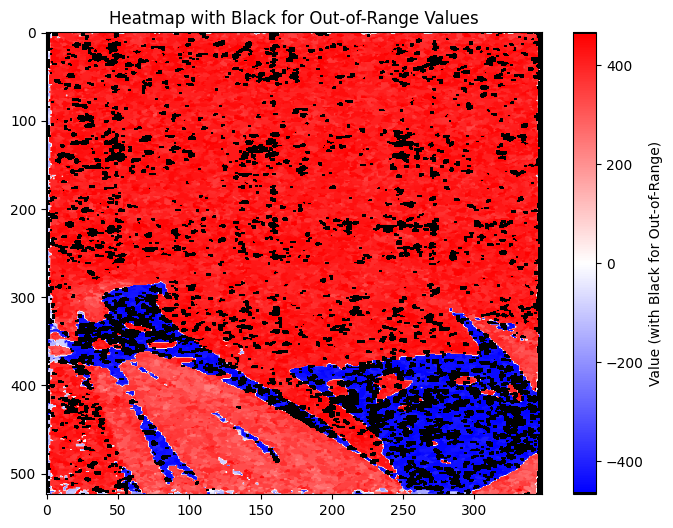

In [12]:
import matplotlib.colors as mcolors
import numpy as np

im = max_positions.copy()

plt.plot(sorted(im.flatten()))
plt.figure(figsize=(10, 10))


vmin, vmax = np.percentile(im, [5, 95])
ill_values_predicate = np.logical_or(im < vmin, im > vmax)
im[ill_values_predicate] = 10e10
vmid = int((vmax + vmin) / 2)
im -= vmid
vmin, vmax = vmin - vmid, vmax - vmid



# print(np.percentile(im, 10))
# plt.imshow(im, aspect="auto", cmap="plasma", vmin=vmin, vmax=vmax)
# plt.imshow(im[im==0], aspect="auto", c, vmin=vmin, vmax=vmax)
# plt.colorbar()

cmap = plt.cm.bwr
colors = cmap(np.linspace(0, 1, 256))  # Get the original colormap colors

centered_norm = mcolors.TwoSlopeNorm(vmin=vmin , vcenter=0, vmax=vmax)

colors = np.vstack(([0, 0, 0, 1], colors, [0, 0, 0, 1]))  # Add black at start and end
custom_cmap = mcolors.ListedColormap(colors)

# Define the boundaries
boundaries = np.linspace(vmin, vmax, 256)  # Define normal range
boundaries = np.concatenate(([im.min()], boundaries, [im.max()]))  # Extend for black

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(im, cmap=custom_cmap, norm=centered_norm, aspect="auto")
plt.colorbar(label="Value (with Black for Out-of-Range)")
plt.title("Heatmap with Black for Out-of-Range Values")
plt.show()


In [ ]:
import torch.nn as nn
import torch.optim as optim
from src.TrainDataGenerator import TrainDataGenerator

X, y = TrainDataGenerator.generate_artificial_data(10000, max_elements_per_sample=3, set_percentages=True, cache_element_samples=False)


class Autoencoder(nn.Module):
    def __init__(self, input_size=2048, hidden_layer_sizes=[1024, 512], latent_dim=64):
        super(Autoencoder, self).__init__()
        
        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_layer_sizes[0]),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_layer_sizes[0], hidden_layer_sizes[1]),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_layer_sizes[1], latent_dim),
            nn.ReLU()
        )
        
        # Decoder layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_layer_sizes[1]),
            nn.ReLU(),
            
            nn.Linear(hidden_layer_sizes[1], hidden_layer_sizes[0]),
            nn.ReLU(),
            
            nn.Linear(hidden_layer_sizes[0], input_size),
            nn.Sigmoid()  # Since XRF spectra are typically in [0,1] range
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Example usage:
# Assuming input size is 2048 features (adjust as needed for your data)
input_size = 2048
model = Autoencoder(input_size=input_size)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Example training loop:
def train_model(model, dataloader, num_epochs=100):
    for epoch in range(num_epochs):
        model.train()
        for batch_features, _ in dataloader:  
            outputs = model(batch_features)
            loss = criterion(outputs, batch_features)  # Reconstruction loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


1667
6671000



100%|██████████| 2/2 [00:00<00:00, 20068.44it/s]

3333


100010003331000





100%|██████████| 4/4 [00:00<00:00, 11602.50it/s]

5000


10001000100010001000






100%|██████████| 5/5 [00:00<00:00, 67216.41it/s]


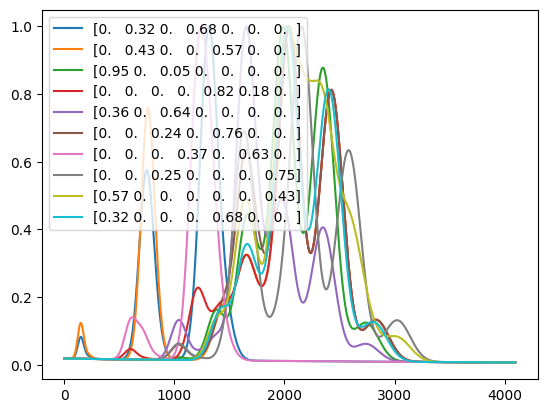

In [13]:
import matplotlib.pyplot as plt 
import numpy as np
for i in range(10):
    plt.plot(X[i+4000], label = f"{np.round(y[i+4000], 2)}")
plt.legend()